# Redes neurais artificais: biblioteca scikit-learn

Francisco Aparecido Rodrigues, francisco@icmc.usp.br.<br>
Universidade de São Paulo, São Carlos, Brasil.<br>
https://sites.icmc.usp.br/francisco <br>

<hr>

## Perceptron

Vamos fazer a classificação usando o perceptron, que é o modelo mais simples de uma rede neural artificial, proposto por Frank Rosenblatt em 1958. Ele é um classificador linear que toma uma entrada, aplica pesos, soma os valores e passa o resultado por uma função de ativação para tomar uma decisão.

<img src="https://lh6.googleusercontent.com/fs9F7Oyzw8jfn7yYRS-s86XF0u086KwEvW25012xc9yLGx0iKmY2oYs19wtEUrvCSPJeLfMDBrdk_7wWkhLmL8_EwBMeSp6Sb-vt4BvA1EqN2z2QjDId3d8at3Io_y-UrOzqp9Km" width=500 />

Vamos implementar o perceptron e aplicar a um conjunto de dados.


Acurácia: 1.0


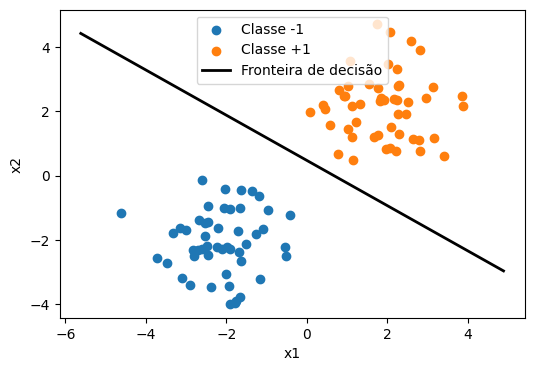

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Geração dos dados
# =========================================================
np.random.seed(42)
# Classe -1
classe1 = np.random.randn(50, 2) + np.array([-2, -2])
# Classe +1
classe2 = np.random.randn(50, 2) + np.array([2, 2])
# Junta os dados
X = np.vstack((classe1, classe2))
# Rótulos
y = np.hstack((-1*np.ones(50), np.ones(50)))

# =========================================================
# Inicialização dos parâmetros
# =========================================================
taxa_aprendizado = 0.01
epocas = 100
# pesos
w = np.zeros(2)
# bias
b = 0
# =========================================================
# Treinamento do Perceptron
# =========================================================

for epoca in range(epocas):
    erros = 0
    for i in range(len(X)):
        # saída linear
        z = np.dot(X[i], w) + b
        # função de ativação (degrau)
        if z >= 0:
            y_pred = 1
        else:
            y_pred = -1
        # cálculo do erro
        erro = y[i] - y_pred
        # atualização dos pesos
        w = w + taxa_aprendizado * erro * X[i]
        # atualização do bias
        b = b + taxa_aprendizado * erro
        # contabiliza erros
        if erro != 0:
            erros += 1
#    print(f'Época {epoca+1}: erros = {erros}')

# =========================================================
# Predição
# =========================================================
y_pred = []
for i in range(len(X)):
    z = np.dot(X[i], w) + b
    if z >= 0:
        y_pred.append(1)
    else:
        y_pred.append(-1)
y_pred = np.array(y_pred)

# =========================================================
# Acurácia
# =========================================================
acuracia = np.mean(y_pred == y)
print('\nAcurácia:', acuracia)

# =========================================================
# Visualização dos dados
# =========================================================
plt.figure(figsize=(6,4))
# Classe -1
plt.scatter(classe1[:,0],classe1[:,1],label='Classe -1')
# Classe +1
plt.scatter(classe2[:,0],classe2[:,1],label='Classe +1')

# =========================================================
# Fronteira de decisão
# =========================================================
x1 = np.linspace(X[:,0].min()-1,X[:,0].max()+1,100)
# reta:
# w1*x + w2*y + b = 0
x2 = -(w[0]*x1 + b)/w[1]
plt.plot(x1,x2,linewidth=2, color = 'black', label='Fronteira de decisão')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(False)
plt.show()

Usando o scikilearn:

Acurácia no teste: 0.856


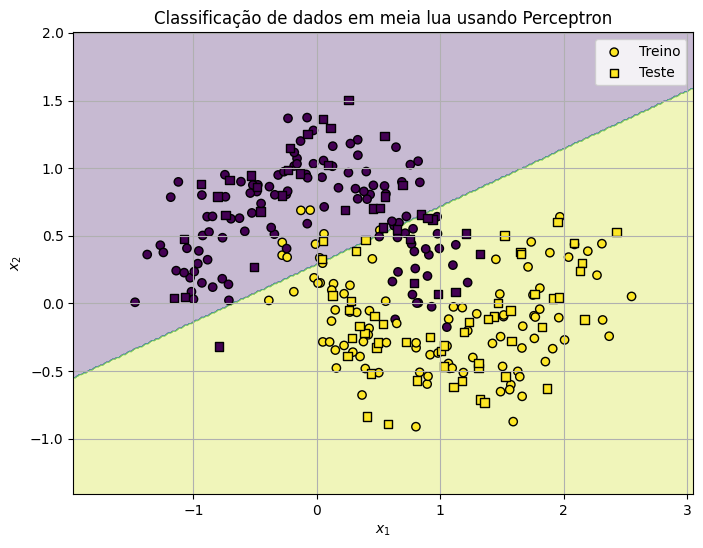

In [21]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# =========================================================
# 1. Gerando os dados em formato de meia lua
# =========================================================

X, y = make_moons(
    n_samples=300,
    noise=0.20,
    random_state=42
)

# Separando em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# =========================================================
# 2. Treinando o Perceptron
# =========================================================

model = Perceptron(
    max_iter=1000,
    eta0=0.1,
    random_state=42
)

model.fit(X_train, y_train)

# Predição no conjunto de teste
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Acurácia no teste: {acc:.3f}")

# =========================================================
# 3. Criando a região de separação
# =========================================================

# Limites do gráfico
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

# Grade de pontos
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Predição em cada ponto da grade
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# =========================================================
# 4. Visualizando os dados e a região de separação
# =========================================================

plt.figure(figsize=(8, 6))

# Região de decisão
plt.contourf(xx, yy, Z, alpha=0.3)

# Dados de treino
plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    edgecolor="k",
    label="Treino"
)

# Dados de teste
plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    marker="s",
    edgecolor="k",
    label="Teste"
)

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Classificação de dados em meia lua usando Perceptron")
plt.legend()
plt.grid(True)
plt.show()

Aplicando a um conjunto de dados reais.

In [22]:
import numpy as np
import pandas as pd

np.random.seed(10)

## se for usar o Colab, descomente
from google.colab import drive
drive.mount('/content/drive/')
#data = pd.read_csv('/content/drive/My Drive/data/Vehicle.csv', header=(0))
data = pd.read_csv('/content/drive/My Drive/data/iris.csv', header=(0))

# se for usar localmente, descomente
# data = pd.read_csv('data/Vehicle.csv', header=(0))
#data = pd.read_csv('data/iris.csv', header=(0))
data.head(10)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [23]:
from sklearn.model_selection import train_test_split

# converte para o numpy
y = data.iloc[:, -1]
data = data.to_numpy()
X = data[:, 0:data.shape[1]-1]

p = 0.8 # fracao de elementos no conjunto de treinamento
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = p, random_state = 42)

In [24]:
from sklearn.preprocessing import StandardScaler  # Normalização dos dados

# faz a padronização dos dados
scaler = StandardScaler()
scaler.fit(X_train)
X_train_std = scaler.transform(X_train)
X_test_std = scaler.transform(X_test)

In [25]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score  # Métrica de avaliação de acurácia


# Faz a classificação utilizando o algoritmo Perceptron
clf = Perceptron(
    max_iter=100,  # Número máximo de iterações para a convergência
    tol=1e-4,  # Critério de tolerância para a parada do treinamento
    eta0=0.1,  # Taxa de aprendizado inicial
    n_jobs=-1,  # Utiliza todos os núcleos do processador para acelerar o treinamento
    random_state=8  # Define a semente para garantir reprodutibilidade dos resultados
)

# Treina o modelo com os dados normalizados de treino
clf.fit(X_train_std, y_train)

# Faz previsões nos dados de teste normalizados
y_pred = clf.predict(X_test_std)

# Calcula e exibe a acurácia do modelo
print('Accuracy score %.2f' % accuracy_score(y_test, y_pred))

Accuracy score 0.90


## Multilayer Perceptron (MLP):

O Multilayer Perceptron (MLP) é um tipo de rede neural artificial feedforward composta por pelo menos três camadas:
* *Camada de entrada*: recebe os dados de entrada.
* *Camadas ocultas*: processam os dados por meio de neurônios (ou nós), aplicando pesos e funções de ativação.
* *Camada de saída*: gera o resultado final, podendo ser um valor contínuo (regressão) ou uma classe (classificação).

<img src="https://cdn-images-1.medium.com/max/800/0*eaw1POHESc--l5yR.png" width=500 />

In [26]:
from sklearn.neural_network import MLPClassifier  # Multi-layer Perceptron para classificação

# Define o classificador MLP (Perceptron Multicamadas)
clf = MLPClassifier(solver='adam', alpha=1e-5,  # Otimizador Adam e regularização L2 com alpha pequeno
                    hidden_layer_sizes=(10, 10),  # Duas camadas ocultas, cada uma com 10 neurônios
                    max_iter=10000,  # Número máximo de iterações para o treinamento
                    random_state=1)  # Define a semente para reprodutibilidade

Aplicando aos dados de meia lua:

Acurácia no teste: 0.967


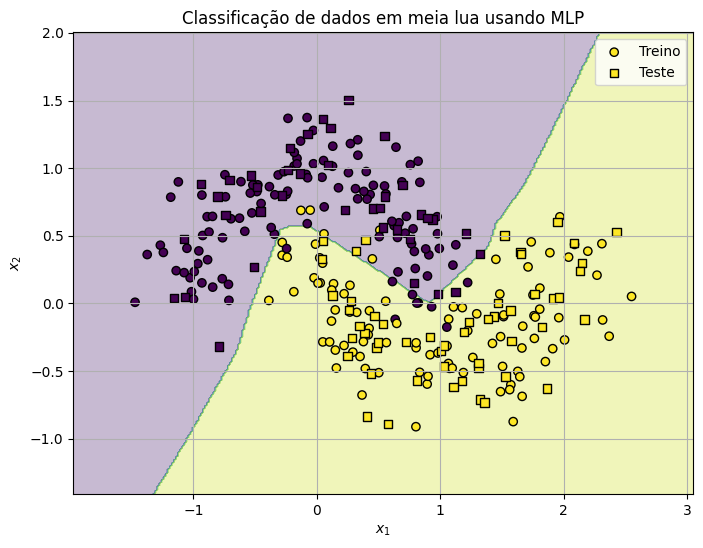

In [27]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# =========================================================
# 1. Gerando os mesmos dados em formato de meia lua
# =========================================================

X, y = make_moons(
    n_samples=300,
    noise=0.20,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# =========================================================
# 2. Treinando a rede neural MLP
# =========================================================

model = MLPClassifier(
    hidden_layer_sizes=(10,10,10),
    activation="relu",
    solver="adam",
    max_iter=2000,
    random_state=42
)

model.fit(X_train, y_train)

# Predição no conjunto de teste
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Acurácia no teste: {acc:.3f}")

# =========================================================
# 3. Criando a região de separação
# =========================================================

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# =========================================================
# 4. Visualizando os dados e a região de separação
# =========================================================

plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    edgecolor="k",
    label="Treino"
)

plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    marker="s",
    edgecolor="k",
    label="Teste"
)

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Classificação de dados em meia lua usando MLP")
plt.legend()
plt.grid(True)
plt.show()

Vamos aplicar o MLP aos dados lidos anteriormente.

In [28]:
# Importa a biblioteca NumPy, usada para operações numéricas
import numpy as np

# Importa a biblioteca Pandas, usada para leitura e manipulação de dados em tabelas
import pandas as pd

# Importa a função usada para dividir os dados em treinamento e teste
from sklearn.model_selection import train_test_split

# Importa o método de padronização dos dados
# A padronização transforma cada variável para ter média 0 e desvio-padrão 1
from sklearn.preprocessing import StandardScaler


# Define a semente do gerador de números aleatórios
# Isso garante que os resultados sejam reprodutíveis
np.random.seed(10)


# =========================================================
# Leitura dos dados
# =========================================================

# Se for usar o Google Colab, descomente as linhas abaixo
from google.colab import drive
drive.mount('/content/drive/')
#data = pd.read_csv('/content/drive/My Drive/data/Vehicle.csv', header=(0))
data = pd.read_csv('/content/drive/My Drive/data/iris.csv', header=(0))


# Se for usar localmente, descomente uma das linhas abaixo
#data = pd.read_csv('data/Vehicle.csv', header=(0))
#data = pd.read_csv('data/iris.csv', header=(0))


# Mostra as 10 primeiras linhas da base de dados
data.head(10)


# =========================================================
# Separação entre atributos e classe
# =========================================================

# Seleciona a última coluna da tabela como variável resposta, isto é, a classe
y = data.iloc[:, -1]

# Converte o DataFrame do Pandas para um array NumPy
data = data.to_numpy()

# Seleciona todas as colunas, exceto a última, como atributos de entrada
X = data[:, 0:data.shape[1]-1]


# =========================================================
# Divisão em conjunto de treinamento e teste
# =========================================================

# Define a fração dos dados que será usada para treinamento
p = 0.8

# Divide os dados em treinamento e teste
# X_train e y_train serão usados para treinar o modelo
# X_test e y_test serão usados para avaliar o modelo
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=p,
    random_state=42
)


# =========================================================
# Padronização dos dados
# =========================================================

# Cria o objeto responsável pela padronização
scaler = StandardScaler()

# Calcula a média e o desvio-padrão usando apenas os dados de treinamento
# Isso evita vazamento de informação do conjunto de teste
scaler.fit(X_train)

# Aplica a padronização ao conjunto de treinamento
X_train_std = scaler.transform(X_train)

# Aplica a mesma transformação ao conjunto de teste
# Importante: usa a média e o desvio-padrão calculados no treinamento
X_test_std = scaler.transform(X_test)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [29]:
from sklearn.neural_network import MLPClassifier  # Multi-layer Perceptron para classificação

# Define o classificador MLP (Perceptron Multicamadas)
clf = MLPClassifier(solver='adam', alpha=1e-5,  # Otimizador Adam e regularização L2 com alpha pequeno
                    hidden_layer_sizes=(10, 10),  # Duas camadas ocultas, cada uma com 10 neurônios
                    max_iter=10000,  # Número máximo de iterações para o treinamento
                    random_state=1)  # Define a semente para reprodutibilidade

clf.fit(X_train, y_train)

MLPClassifier(alpha=1e-05, hidden_layer_sizes=(10, 10), max_iter=10000,
              random_state=1)

In [30]:
y_pred = clf.predict(X_test)
print('Accuracy score %.2f' % accuracy_score(y_test, y_pred))

Accuracy score 0.97


Podemos verificar a classificação de acordo com o número de épocas:

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Número de linhas e colunas: (846, 19)
Acurácia final: 0.8882


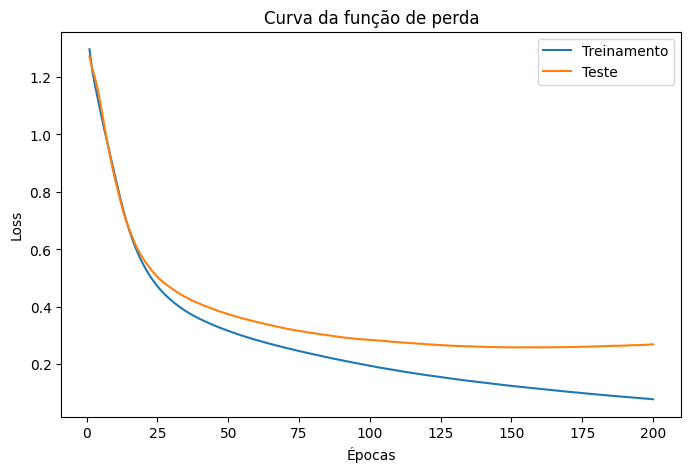

In [31]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, log_loss

np.random.seed(10)

## se for usar o Colab, descomente
from google.colab import drive
drive.mount('/content/drive/')
data = pd.read_csv('/content/drive/My Drive/data/Vehicle.csv', header=(0))
#data = pd.read_csv('/content/drive/My Drive/dados/iris.csv', header=(0))

# se for usar localmente, descomente
#data = pd.read_csv('data/Vehicle.csv', header=(0))
#data = pd.read_csv('data/iris.csv', header=(0))

print("Número de linhas e colunas:", data.shape)
data.head(10)

# =========================================================
# 1. Prepara os dados
# =========================================================
X = data.drop('Class', axis=1)
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalização
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================================================
# 2. Inicializa o modelo
# =========================================================
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    random_state=42,
    max_iter=1,          # uma época por vez
    warm_start=True      # mantém os pesos entre as chamadas
)

# =========================================================
# 3. Treinamento manual por épocas
# =========================================================
n_epochs = 200

train_losses = []
test_losses = []

classes = np.unique(y_train)

for epoch in range(n_epochs):
    # Treina uma época
    if epoch == 0:
        mlp.partial_fit(X_train, y_train, classes=classes)
    else:
        mlp.partial_fit(X_train, y_train)

    # Probabilidades previstas
    y_train_prob = mlp.predict_proba(X_train)
    y_test_prob = mlp.predict_proba(X_test)

    # Calcula a loss (log-loss)
    train_loss = log_loss(y_train, y_train_prob)
    test_loss = log_loss(y_test, y_test_prob)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

# =========================================================
# 4. Avaliação final
# =========================================================
y_pred = mlp.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia final: {accuracy:.4f}")

# =========================================================
# 5. Plot das curvas
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(range(1, n_epochs + 1), train_losses, label='Treinamento')
plt.plot(range(1, n_epochs + 1), test_losses, label='Teste')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.title('Curva da função de perda')
plt.legend()
plt.grid(False)
plt.show()

## Classificação de dados não lineares

Vamos considerar dados que não são linearmente separáveis e fazer a classificação usando um classificador linear, como a regressão logística.

Acurácia na regressão logística: 0.86


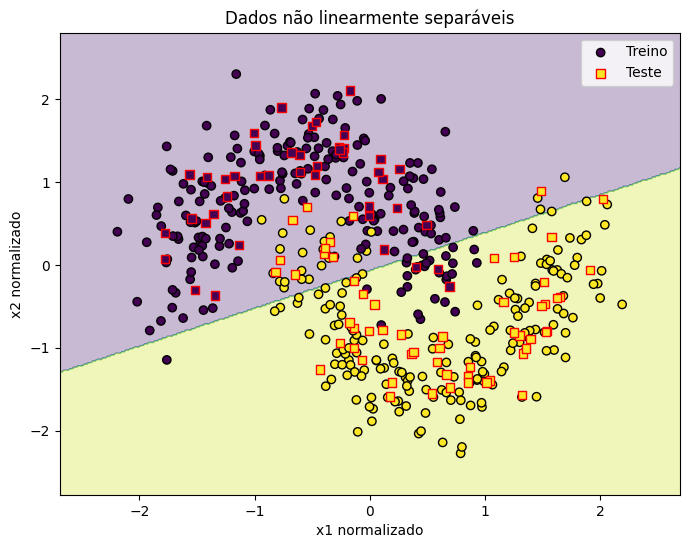

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Dados
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)

# Divisão treino/teste
p = 0.8 # fracao de elementos no conjunto de treinamento
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = p, random_state = 42)

# Normalização
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Modelo
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

print("Acurácia na regressão logística:", log_reg.score(X_test, y_test))
# =========================================================
# Região de separação
# =========================================================
# limites do gráfico usando os dados normalizados
x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5

# malha de pontos
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# classificar todos os pontos da malha
grid = np.c_[xx.ravel(), yy.ravel()]
Z = log_reg.predict(grid)
Z = Z.reshape(xx.shape)

# gráfico
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

plt.scatter(X_train[:, 0], X_train[:, 1],c=y_train, cmap='viridis',edgecolor='k',label='Treino')

plt.scatter(X_test[:, 0], X_test[:, 1],c=y_test, cmap='viridis',edgecolor='red',marker='s',label='Teste')

plt.xlabel("x1 normalizado")
plt.ylabel("x2 normalizado")
plt.title("Dados não linearmente separáveis")
plt.legend()
plt.show()

Vamos agora considerar uma rede neural.

Acurácia: 0.98


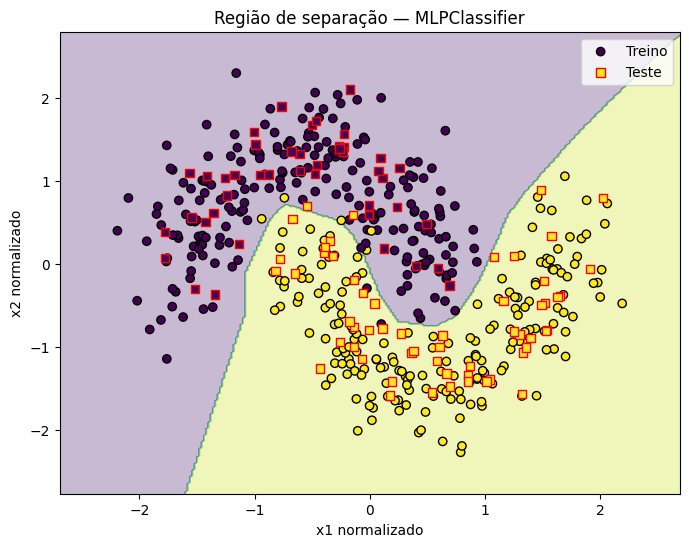

In [33]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Modelo MLP
# =========================================================
mlp = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred))

# =========================================================
# Função para mostrar a região de separação
# =========================================================
def plot_decision_boundary(model, X_train, y_train, X_test, y_test):
    h = 0.02
    x_min = min(X_train[:, 0].min(), X_test[:, 0].min()) - 0.5
    x_max = max(X_train[:, 0].max(), X_test[:, 0].max()) + 0.5
    y_min = min(X_train[:, 1].min(), X_test[:, 1].min()) - 0.5
    y_max = max(X_train[:, 1].max(), X_test[:, 1].max()) + 0.5

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))

    # Região de decisão
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

    # Pontos de treino
    plt.scatter(
        X_train[:, 0], X_train[:, 1],
        c=y_train,
        cmap='viridis',
        edgecolor='k',
        label='Treino'
    )

    # Pontos de teste
    plt.scatter(
        X_test[:, 0], X_test[:, 1],
        c=y_test,
        cmap='viridis',
        edgecolor='red',
        marker='s',
        label='Teste'
    )

    plt.xlabel("x1 normalizado")
    plt.ylabel("x2 normalizado")
    plt.title("Região de separação — MLPClassifier")
    plt.legend()
    plt.show()

plot_decision_boundary(mlp, X_train, y_train, X_test, y_test)

Considerando outras configurações de hiperparâmetros:

In [34]:
for neurons in [1, 5, 20, 100]:
    model = MLPClassifier(hidden_layer_sizes=(neurons,), max_iter=10000)
    model.fit(X_train, y_train)
    print(f"Neurônios: {neurons}, Acurácia: {model.score(X_test, y_test):.3f}")

Neurônios: 1, Acurácia: 0.840
Neurônios: 5, Acurácia: 0.850
Neurônios: 20, Acurácia: 0.980
Neurônios: 100, Acurácia: 0.980


A curva de aprendizado:

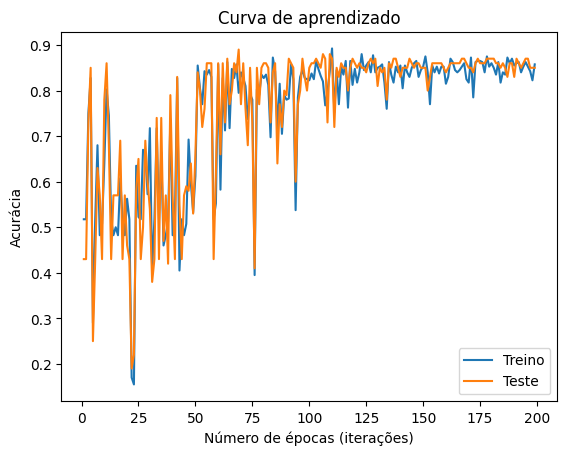

In [35]:
# se quiser evitar as mensagens de Warning, descomente
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

train_scores = []
test_scores = []

# “O que acontece se eu parar o treinamento cedo demais?”
for i in range(1, 200):
    model = MLPClassifier(hidden_layer_sizes=(10,), max_iter=i)
    # max_iter é o número de épocas
    # note que para valores pequenos de max_iter, o algoritmo ainda não teve tempo de convergir
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

# eixo x (épocas)
epochs = range(1, 200)
plt.plot(epochs, train_scores, label="Treino")
plt.plot(epochs, test_scores, label="Teste")
plt.xlabel("Número de épocas (iterações)")
plt.ylabel("Acurácia")
plt.title("Curva de aprendizado")
plt.legend()
plt.show()

Note que:
* Poucas épocas → modelo mal treinado (underfitting)
* Muitas épocas → melhor ajuste (ou até overfitting)

## Regressão

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(10)

# se for usar o Colab, descomente
from google.colab import drive
drive.mount('/content/drive/')
data = pd.read_csv('/content/drive/My Drive/data/concrete_data.csv', header=(0))

# se for usar localmente, descomente
#data = pd.read_csv('data/concrete_data.csv', header=(0))

print("Número de linhas e colunas:", data.shape)
data.head(10)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Número de linhas e colunas: (1030, 9)


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
5,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.03
6,380.0,95.0,0.0,228.0,0.0,932.0,594.0,365,43.70
7,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.45
8,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
9,475.0,0.0,0.0,228.0,0.0,932.0,594.0,28,39.29


MSE  = 31.8497
RMSE = 5.6435
R²   = 0.8764


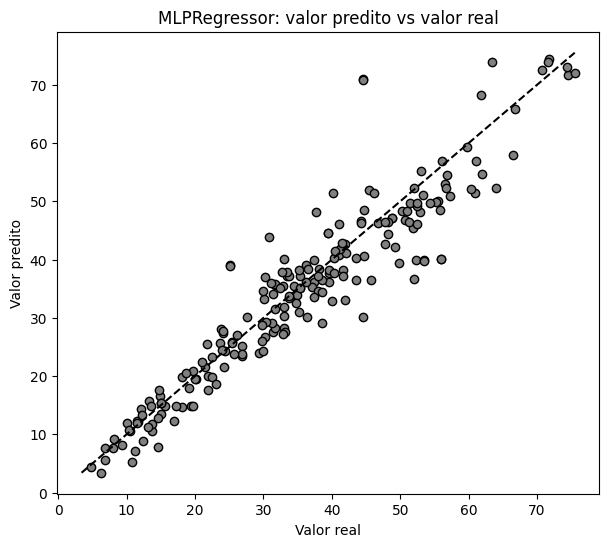

In [37]:
# =========================================================
# Separar atributos e alvo
# Assume que a última coluna é a variável resposta
# =========================================================
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# =========================================================
# Dividir em treino e teste
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================================
# Normalização
# =========================================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================================================
# Modelo MLP para regressão
# =========================================================
mlp = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=42
)

mlp.fit(X_train, y_train)

# =========================================================
# Predições
# =========================================================
y_pred = mlp.predict(X_test)

# =========================================================
# Métricas
# =========================================================
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2:.4f}")

# =========================================================
# Gráfico: valores reais vs preditos
# =========================================================
plt.figure(figsize=(7, 6))
plt.plot(y_test, y_pred, 'o', color='gray', markersize=6, markerfacecolor='gray', markeredgecolor='black')

# linha ideal y = x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--')

plt.xlabel("Valor real")
plt.ylabel("Valor predito")
plt.title("MLPRegressor: valor predito vs valor real")
plt.grid(False)
plt.show()

MSE  = 31.8497
RMSE = 5.6435
R²   = 0.8764


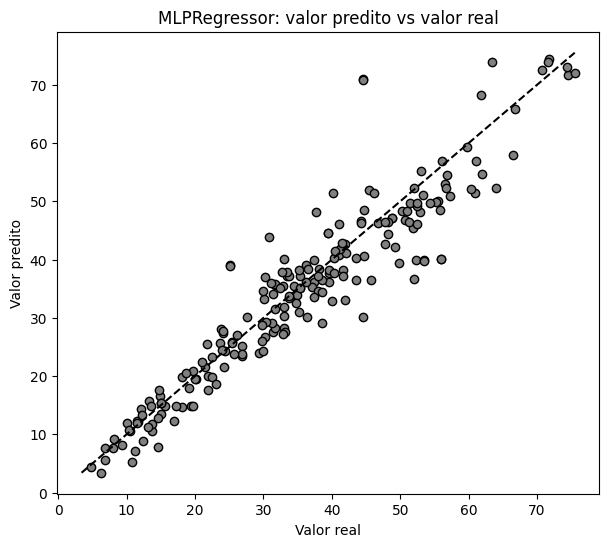

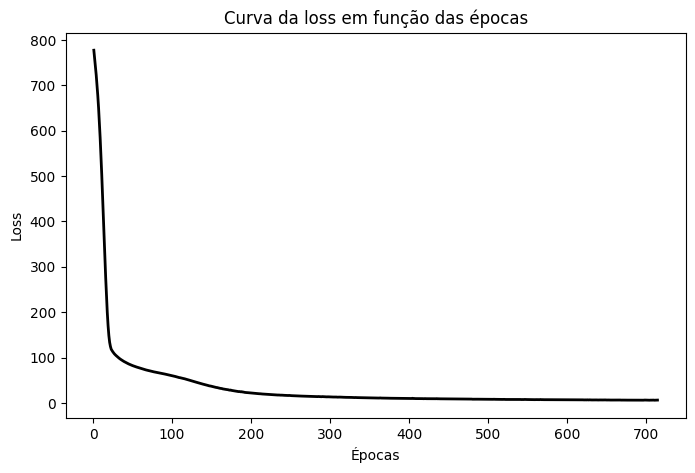

In [38]:
# =========================================================
# Separar atributos e alvo
# Assume que a última coluna é a variável resposta
# =========================================================
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# =========================================================
# Dividir em treino e teste
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================================
# Normalização
# =========================================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================================================
# Modelo MLP para regressão
# =========================================================
mlp = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=42
)

mlp.fit(X_train, y_train)

# =========================================================
# Predições
# =========================================================
y_pred = mlp.predict(X_test)

# =========================================================
# Métricas
# =========================================================
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2:.4f}")

# =========================================================
# Gráfico: valores reais vs preditos
# =========================================================
plt.figure(figsize=(7, 6))
plt.plot(y_test, y_pred, 'o', color='gray', markersize=6,
         markerfacecolor='gray', markeredgecolor='black')

# linha ideal y = x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--')

plt.xlabel("Valor real")
plt.ylabel("Valor predito")
plt.title("MLPRegressor: valor predito vs valor real")
plt.grid(False)
plt.show()

# =========================================================
# Gráfico da loss em função das épocas
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(mlp.loss_curve_) + 1), mlp.loss_curve_, 'k-', linewidth=2)

plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Curva da loss em função das épocas")
plt.grid(False)
plt.show()

## Seleção e ajuste de modelos

In [39]:
## se for usar o Colab, descomente
from google.colab import drive
drive.mount('/content/drive/')
data = pd.read_csv('/content/drive/My Drive/data/Vehicle.csv', header=(0))
#data = pd.read_csv('/content/drive/My Drive/dados/iris.csv', header=(0))

# se for usar localmente, descomente
#data = pd.read_csv('data/Vehicle.csv', header=(0))
#data = pd.read_csv('data/iris.csv', header=(0))

print("Número de linhas e colunas:", data.shape)
data.head(10)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Número de linhas e colunas: (846, 19)


,Comp,Circ,D.Circ,Rad.Ra,Pr.Axis.Ra,Max.L.Ra,Scat.Ra,Elong,Pr.Axis.Rect,Max.L.Rect,Sc.Var.Maxis,Sc.Var.maxis,Ra.Gyr,Skew.Maxis,Skew.maxis,Kurt.maxis,Kurt.Maxis,Holl.Ra,Class
0,95,48,83,178,72,10,162,42,20,159,176,379,184,70,6,16,187,197,van
1,91,41,84,141,57,9,149,45,19,143,170,330,158,72,9,14,189,199,van
2,104,50,106,209,66,10,207,32,23,158,223,635,220,73,14,9,188,196,saab
3,93,41,82,159,63,9,144,46,19,143,160,309,127,63,6,10,199,207,van
4,85,44,70,205,103,52,149,45,19,144,241,325,188,127,9,11,180,183,bus
5,107,57,106,172,50,6,255,26,28,169,280,957,264,85,5,9,181,183,bus
6,97,43,73,173,65,6,153,42,19,143,176,361,172,66,13,1,200,204,bus
7,90,43,66,157,65,9,137,48,18,146,162,281,164,67,3,3,193,202,van
8,86,34,62,140,61,7,122,54,17,127,141,223,112,64,2,14,200,208,van
9,93,44,98,197,62,11,183,36,22,146,202,505,152,64,4,14,195,204,saab


In [40]:
from sklearn.model_selection import GridSearchCV

# Prepara os dados
X = data.drop(data.columns[-1], axis=1)  # Atributos (features)
y = data[data.columns[-1]]  # Variável alvo (target)

# Divide os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalização das características (importante para redes neurais)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define a grade de parâmetros para o GridSearchCV
parameter_space = {
    'hidden_layer_sizes': [(50, 50), (100,), (50,100,50)],  # Diferentes configurações para o número de neurônios nas camadas ocultas
    'activation': ['tanh', 'relu'],  # Funções de ativação a serem testadas
    # 'solver': ['sgd', 'adam'],  # Algoritmos de otimização (comentado para simplificação)
    # 'alpha': [0.0001, 0.05],  # Regularização (comentado para simplificação)
    # 'learning_rate': ['constant', 'adaptive'],  # Taxa de aprendizado (comentado para simplificação)
}

# Inicializa o classificador MLP
mlp = MLPClassifier(max_iter=10000, random_state=42)  # Define o número máximo de iterações e a semente aleatória

# Cria o objeto GridSearchCV
clf = GridSearchCV(mlp, parameter_space, n_jobs=-1, cv=5)  # Usa validação cruzada com 5 divisões e múltiplos núcleos para paralelismo

# Ajusta o GridSearchCV aos dados de treinamento
clf.fit(X_train, y_train)

# Exibe os melhores parâmetros encontrados e a melhor pontuação de validação cruzada
print('Melhores parâmetros encontrados:\n', clf.best_params_)
print('Melhor pontuação de CV:\n', clf.best_score_)

# Avalia o melhor modelo no conjunto de teste
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia no teste com os melhores parâmetros: {accuracy}")

Melhores parâmetros encontrados:
 {'activation': 'tanh', 'hidden_layer_sizes': (50, 100, 50)}
Melhor pontuação de CV:
 0.8327995642701526
Acurácia no teste com os melhores parâmetros: 0.8764705882352941


Vamos analisar o efeito do número de épocas.

Melhor época: 258
Melhor acurácia de validação: 0.8676


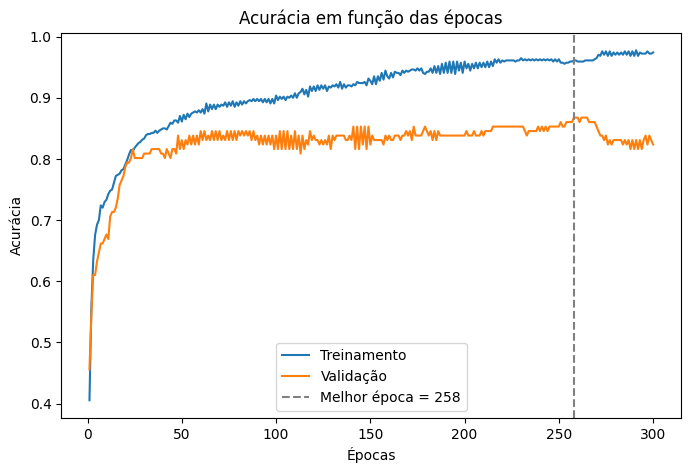

In [41]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# =========================================================
# Separar treino em treino + validação
# =========================================================
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# =========================================================
# Modelo com os melhores parâmetros do GridSearchCV
# =========================================================
best_params = clf.best_params_

mlp_epoch = MLPClassifier(
    **best_params,
    max_iter=1,
    warm_start=True,
    random_state=42
)

# =========================================================
# Treinamento época por época
# =========================================================
n_epochs = 300

train_acc = []
val_acc = []

for epoch in range(n_epochs):
    mlp_epoch.fit(X_tr, y_tr)

    y_tr_pred = mlp_epoch.predict(X_tr)
    y_val_pred = mlp_epoch.predict(X_val)

    train_acc.append(accuracy_score(y_tr, y_tr_pred))
    val_acc.append(accuracy_score(y_val, y_val_pred))

# =========================================================
# Melhor época pela validação
# =========================================================
best_epoch = np.argmax(val_acc) + 1
best_val_acc = np.max(val_acc)

print(f"Melhor época: {best_epoch}")
print(f"Melhor acurácia de validação: {best_val_acc:.4f}")

# =========================================================
# Gráfico
# =========================================================
plt.figure(figsize=(8, 5))

plt.plot(range(1, n_epochs + 1), train_acc, label="Treinamento")
plt.plot(range(1, n_epochs + 1), val_acc, label="Validação")

plt.axvline(best_epoch, linestyle="--", color="gray",
            label=f"Melhor época = {best_epoch}")

plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.title("Acurácia em função das épocas")
plt.legend()
plt.grid(False)
plt.show()

Vamos reajustar o modelo utilizando os melhores hiperparâmetros encontrados e o número ótimo de épocas, estimado a partir do desempenho no conjunto de validação. Em seguida, avaliaremos o desempenho final no conjunto de teste.

In [42]:
# =========================================================
# Reajustar o modelo com o melhor número de épocas
# usando treino + validação
# =========================================================
mlp_best_epoch = MLPClassifier(
    **best_params,
    max_iter=best_epoch,
    random_state=42
)

mlp_best_epoch.fit(X_train, y_train)

# =========================================================
# Avaliação final no conjunto de teste
# =========================================================
y_test_pred = mlp_best_epoch.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Melhor número de épocas: {best_epoch}")
print(f"Acurácia final no teste: {test_accuracy:.4f}")

Melhor número de épocas: 258
Acurácia final no teste: 0.8765


Podemos mostrar a matriz de confusão:

              precision    recall  f1-score   support

         bus       1.00      1.00      1.00        52
        opel       0.68      0.77      0.72        30
        saab       0.80      0.75      0.77        48
         van       0.97      0.95      0.96        40

    accuracy                           0.88       170
   macro avg       0.86      0.87      0.86       170
weighted avg       0.88      0.88      0.88       170



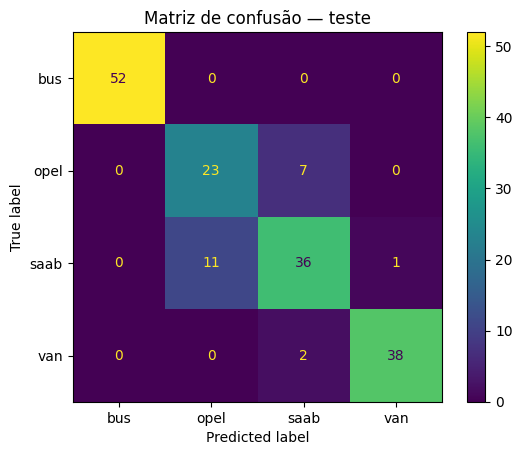

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=mlp_best_epoch.classes_
)

disp.plot()
plt.title("Matriz de confusão — teste")
plt.grid(False)
plt.show()

Vamos mostrar a curva de aprendizado para verificarmos se não há overfitting.

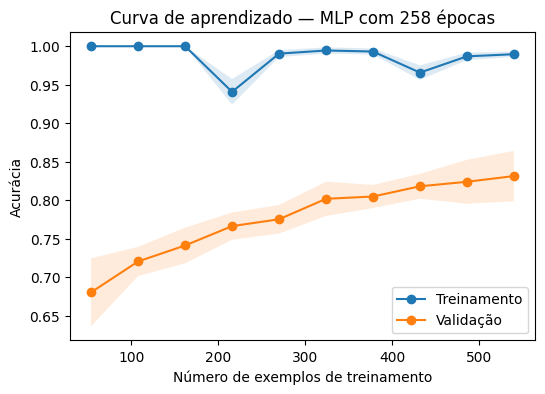

In [44]:
from sklearn.model_selection import learning_curve
from sklearn.neural_network import MLPClassifier
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Modelo com melhores hiperparâmetros e melhor número de épocas
# =========================================================
mlp_best = MLPClassifier(
    **best_params,
    max_iter=best_epoch,
    random_state=42
)

# =========================================================
# Curva de aprendizado
# =========================================================
train_sizes, train_scores, val_scores = learning_curve(
    estimator=mlp_best,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

# Médias e desvios padrão
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# =========================================================
# Gráfico
# =========================================================
plt.figure(figsize=(6, 4))

plt.plot(train_sizes, train_mean, 'o-', label='Treinamento')
plt.plot(train_sizes, val_mean, 'o-', label='Validação')

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.15
)

plt.xlabel("Número de exemplos de treinamento")
plt.ylabel("Acurácia")
plt.title(f"Curva de aprendizado — MLP com {best_epoch} épocas")
plt.legend()
plt.grid(False)
plt.savefig('aprendizado.jpg')
plt.show()

Vemos que há um indício, mesmo que leve de overfitting. Para reduzir, usamos uma rede menor, regularização alpha e early_stopping=True.

In [45]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

parameter_space = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.00001, 0.0001, 0.001, 0.005, 0.01],
    'learning_rate_init': [0.001, 0.0005]
}

mlp = MLPClassifier(
    solver="adam",
    max_iter=3000,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=50,
    random_state=42
)

clf = GridSearchCV(
    mlp,
    parameter_space,
    n_jobs=-1,
    cv=10,
    scoring='accuracy'
)

clf.fit(X_train, y_train)

print("Melhores parâmetros:")
print(clf.best_params_)

print("Melhor acurácia média na validação cruzada:")
print(clf.best_score_)

ValueError: 
All the 800 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
800 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py", line 754, in fit
    return self._fit(X, y, incremental=False)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model = clf.best_estimator_

y_pred = best_model.predict(X_test)

print("Acurácia no teste:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.classes_
)

disp.plot()
plt.title("Matriz de confusão — modelo regularizado")
plt.grid(False)
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(best_model.validation_scores_, label="Validação")
plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.title("Acurácia de validação durante o treinamento")
plt.legend()
plt.grid(False)
plt.show()

print("Número de épocas usadas:", best_model.n_iter_)

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_model,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Treinamento')
plt.plot(train_sizes, val_mean, 'o-', label='Validação')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)

plt.xlabel("Número de exemplos de treinamento")
plt.ylabel("Acurácia")
plt.title("Curva de aprendizado — MLP regularizada")
plt.legend()
plt.grid(False)
plt.show()

Agora notamos que o overfitting foi reduzido, mas houve uma queda na acurácia do modelo.

## Exercícios

1 — Classificação da base Seeds

Faça a classificação da base Seeds:
https://archive-beta.ics.uci.edu/dataset/236/seeds

Use redes neurais artificiais com o MLPClassifier do scikit-learn.

a) Avalie a influência do tamanho do batch na classificação.

b) Avalie a influência do número de camadas e do número de neurônios por camada na classificação.

c) Avalie a influência de diferentes funções de ativação na classificação.

d) Avalie a influência da inicialização aleatória dos pesos na classificação. Para isso, execute a mesma arquitetura de rede neural várias vezes, alterando apenas o valor de random_state. Compare a acurácia média, o desvio padrão da acurácia e a matriz de confusão obtidos em diferentes execuções. Os resultados são estáveis? Em seguida, discuta por que inicializações inadequadas, como todos os pesos iguais a zero, podem prejudicar o treinamento de redes neurais.

e) Avalie a influência da padronização dos atributos no desempenho da rede neural. Compare os resultados com e sem StandardScaler.

f) Compare a normalização Min-Max com a padronização Z-score.

g) Avalie a influência da taxa de aprendizado na classificação. Teste diferentes valores de learning_rate_init, como 0.0001, 0.001, 0.01 e 0.1.

h) Avalie a influência do número máximo de iterações no desempenho do modelo. Faça gráficos da acurácia nos conjuntos de treinamento e teste em função de max_iter.

i) Mostre a curva da função de perda ao longo das iterações. O modelo parece convergir?

j) Compare os otimizadores adam, sgd e lbfgs. Discuta as diferenças em termos de desempenho, estabilidade e tempo de treinamento.

k) Avalie a influência do parâmetro de regularização alpha. Teste valores como 0.0001, 0.001, 0.01, 0.1 e 1.

2 — Classificação da base Dry Bean

Faça a classificação da base Dry Bean:
https://archive-beta.ics.uci.edu/dataset/602/dry+bean+dataset

Use redes neurais artificiais com o MLPClassifier do scikit-learn.

a) Use técnicas de ajuste de modelos para selecionar os melhores hiperparâmetros. Utilize validação cruzada e considere os seguintes hiperparâmetros:

* número de camadas;
* número de neurônios por camada;
* função de ativação;
* taxa de aprendizado;
* regularização alpha;
* tamanho do batch;
* otimizador.

b) Avalie a curva de aprendizado para verificar se há overfitting. Caso haja, tente reduzi-lo.

c) Além da acurácia, calcule precisão, revocação, F1-score e a matriz de confusão.

d) Verifique se há classes mais difíceis de classificar. Use a matriz de confusão para justificar sua resposta.

e) Compare a rede neural com classificadores mais simples, como regressão logística, k-NN, árvore de decisão e SVM. A rede neural apresenta, de fato, melhor desempenho?

f) Construa um Pipeline completo, incluindo a padronização dos dados e o classificador neural. Construa a partir do código a seguir.

In [ ]:
from sklearn.pipeline import Pipeline

model = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(max_iter=1000, random_state=42))
])